In [1]:
import pandas as pd
import os

In [2]:
file_name = "Chocolate Sales.csv"

data_path = os.path.join("../datasets/raw/", file_name)
df = pd.read_csv(data_path)
df.columns = df.columns.str.strip()

In [3]:
print('---------------- INFO ---------------------\n')
print(df.info(), '\n')

print('------------ DESCRIBE -------------\n')
print(df.describe(), '\n')

print('------------- NULL VALUES -----------\n')
print(df.isna().sum(), '\n')

print('------------- DUPLICATED SAMPLE -----------\n')
print(df.duplicated().sum(), '\n')

print('------------ HEAD -----------------\n', )
print(df.head(), '\n')

---------------- INFO ---------------------

<class 'pandas.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Sales Person   3282 non-null   str  
 1   Country        3282 non-null   str  
 2   Product        3282 non-null   str  
 3   Date           3282 non-null   str  
 4   Amount         3282 non-null   str  
 5   Boxes Shipped  3282 non-null   int64
dtypes: int64(1), str(5)
memory usage: 154.0 KB
None 

------------ DESCRIBE -------------

       Boxes Shipped
count    3282.000000
mean      164.666971
std       124.024736
min         1.000000
25%        71.000000
50%       137.000000
75%       232.000000
max       778.000000 

------------- NULL VALUES -----------

Sales Person     0
Country          0
Product          0
Date             0
Amount           0
Boxes Shipped    0
dtype: int64 

------------- DUPLICATED SAMPLE -----------

0 

------------ HEAD ------

In [5]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

df.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped,Month,Year
0,Jehu Rudeforth,UK,Mint Chip Choco,2022-01-04,"$5,320.00",180,1,2022
1,Van Tuxwell,India,85% Dark Bars,2022-08-01,"$7,896.00",94,8,2022
2,Gigi Bohling,India,Peanut Butter Cubes,2022-07-07,"$4,501.00",91,7,2022
3,Jan Morforth,Australia,Peanut Butter Cubes,2022-04-27,"$12,726.00",342,4,2022
4,Jehu Rudeforth,UK,Peanut Butter Cubes,2022-02-24,"$13,685.00",184,2,2022


In [6]:
df = df.drop(columns=['Sales Person', 'Date'])

In [7]:
df = df.rename(columns={
    'Boxes Shipped': 'Boxes_Shipped'
})

df.head()

,Country,Product,Amount,Boxes_Shipped,Month,Year
0,UK,Mint Chip Choco,"$5,320.00",180,1,2022
1,India,85% Dark Bars,"$7,896.00",94,8,2022
2,India,Peanut Butter Cubes,"$4,501.00",91,7,2022
3,Australia,Peanut Butter Cubes,"$12,726.00",342,4,2022
4,UK,Peanut Butter Cubes,"$13,685.00",184,2,2022


In [8]:
print('------------- Country Column Values ---------------\n', df['Country'].unique(), '\n')
print('------------- Product Column Values ---------------\n', df['Product'].unique(), '\n')

------------- Country Column Values ---------------
 <StringArray>
['UK', 'India', 'Australia', 'New Zealand', 'USA', 'Canada']
Length: 6, dtype: str 

------------- Product Column Values ---------------
 <StringArray>
[     'Mint Chip Choco',        '85% Dark Bars',  'Peanut Butter Cubes',
   'Smooth Sliky Salty',      '99% Dark & Pure',          'After Nines',
       '50% Dark Bites',         'Orange Choco',              'Eclairs',
        'Drinking Coco',  'Organic Choco Syrup',            'Milk Bars',
  'Spicy Special Slims',     'Fruit & Nut Bars',           'White Choc',
   'Manuka Honey Choco',         'Almond Choco',      'Raspberry Choco',
 'Choco Coated Almonds',  'Baker's Choco Chips', 'Caramel Stuffed Bars',
       '70% Dark Bites']
Length: 22, dtype: str 



In [9]:
print(df.columns)

df['Amount'] = pd.to_numeric(
    df['Amount'].astype(str).str.replace(r'[\$,]', '', regex=True)
)

df.head()

Index(['Country', 'Product', 'Amount', 'Boxes_Shipped', 'Month', 'Year'], dtype='str')


,Country,Product,Amount,Boxes_Shipped,Month,Year
0,UK,Mint Chip Choco,5320.0,180,1,2022
1,India,85% Dark Bars,7896.0,94,8,2022
2,India,Peanut Butter Cubes,4501.0,91,7,2022
3,Australia,Peanut Butter Cubes,12726.0,342,4,2022
4,UK,Peanut Butter Cubes,13685.0,184,2,2022


In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_copy = df.copy()

df_copy['Country'] = le.fit_transform(df_copy['Country'])
df_copy['Product'] = le.fit_transform(df_copy['Product'])

df_copy.head()

,Country,Product,Amount,Boxes_Shipped,Month,Year
0,4,14,5320.0,180,1,2022
1,2,2,7896.0,94,8,2022
2,2,17,4501.0,91,7,2022
3,0,17,12726.0,342,4,2022
4,4,17,13685.0,184,2,2022


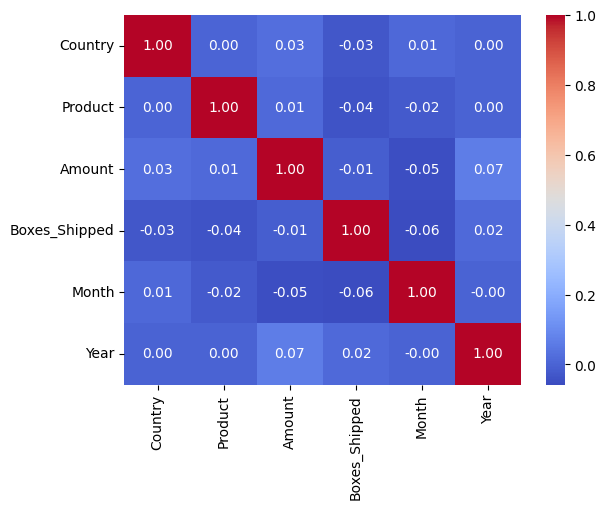

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df_copy.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

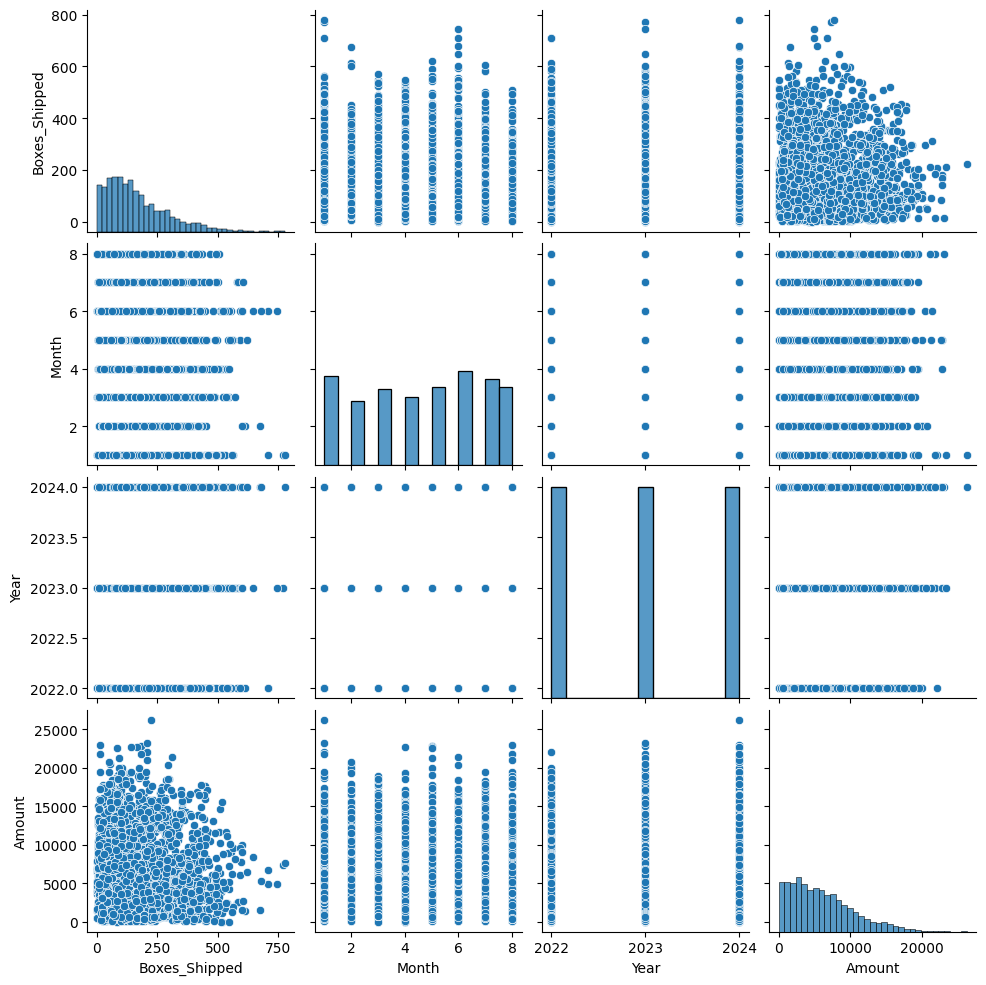

In [12]:
sns.pairplot(df[['Boxes_Shipped', 'Month', 'Year', 'Amount']])
plt.show()

In [13]:
df = df.drop(columns=['Year'])

In [14]:
import numpy as np

df['log_amount'] = np.log1p(df['Amount'])

df.head()

,Country,Product,Amount,Boxes_Shipped,Month,log_amount
0,UK,Mint Chip Choco,5320.0,180,1,8.579417
1,India,85% Dark Bars,7896.0,94,8,8.974238
2,India,Peanut Butter Cubes,4501.0,91,7,8.412277
3,Australia,Peanut Butter Cubes,12726.0,342,4,9.451481
4,UK,Peanut Butter Cubes,13685.0,184,2,9.524129


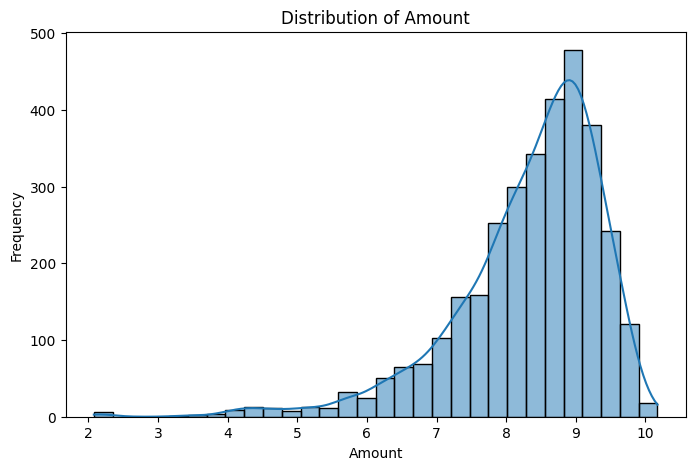

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df['log_amount'], bins=30, kde=True)
plt.title("Distribution of Amount")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

In [16]:
import os

os.makedirs("../datasets/processed", exist_ok=True)

df.to_csv("../datasets/processed/processed_chocolate_sales.csv", index=False)